<a href="https://colab.research.google.com/github/Artty02/Assignment/blob/main/Deep_Learning2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wandb

In [2]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model, load_model
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
import wandb

In [3]:
import shutil

checkpoint_path = "/content/dataset/.ipynb_checkpoints"

# ตรวจสอบว่ามีโฟลเดอร์อยู่จริงก่อนลบ
if os.path.exists(checkpoint_path):
    shutil.rmtree(checkpoint_path)
    print("Deleted .ipynb_checkpoints successfully!")
else:
    print(".ipynb_checkpoints not found.")


Deleted .ipynb_checkpoints successfully!


In [4]:
import shutil

CHECKPOINTS_PATH = "/content/Test/.ipynb_checkpoints"

# ถ้ามีโฟลเดอร์นี้อยู่ ให้ลบทิ้งเลย
if os.path.exists(CHECKPOINTS_PATH):
    shutil.rmtree(CHECKPOINTS_PATH)
    print("✅ ลบ .ipynb_checkpoints สำเร็จ!")
else:
    print("🔍 ไม่พบ .ipynb_checkpoints ใน Test Set")


✅ ลบ .ipynb_checkpoints สำเร็จ!


In [5]:
!pip install wandb --upgrade

In [6]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model, load_model
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
import wandb

In [7]:
dataset_path = "./dataset"  # ระบุ path ของ dataset
classes = ["Basketball", "Training", "Futsal", "Running"]

In [ ]:
# Part 1 : Dataset description

In [8]:
# Exploratory Data Analysis (EDA)

class_counts = {}
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    if os.path.exists(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images

df_counts = pd.DataFrame(list(class_counts.items()), columns=["Class", "Number of Images"])
print(df_counts)


        Class  Number of Images
0  Basketball                76
1    Training                71
2      Futsal                80
3     Running                83


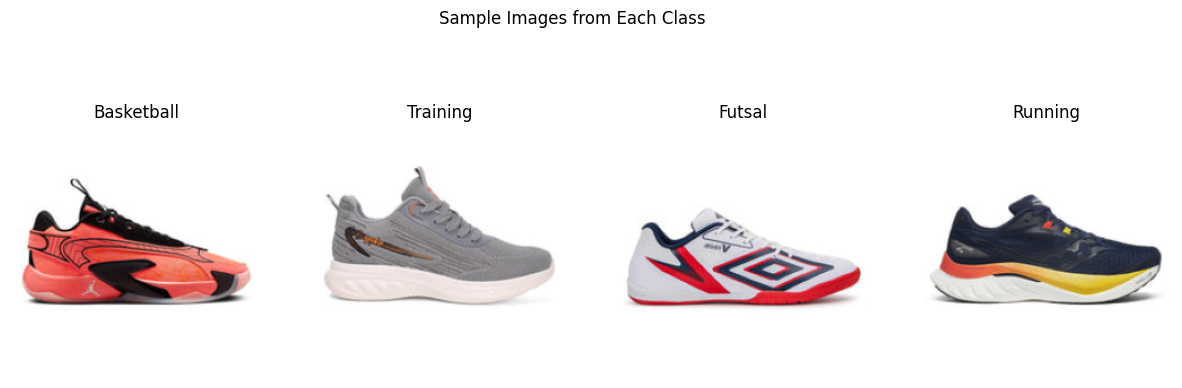

In [9]:
# แสดงตัวอย่างภาพจาก dataset

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)
    sample_image = random.choice(os.listdir(class_path))
    img = cv2.imread(os.path.join(class_path, sample_image))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    img = cv2.resize(img, (224, 224))  # Resize for visualization

    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.suptitle("Sample Images from Each Class")
plt.show()


<ipython-input-10-6229e40da46e>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_counts["Class"], y=df_counts["Number of Images"], palette="viridis")


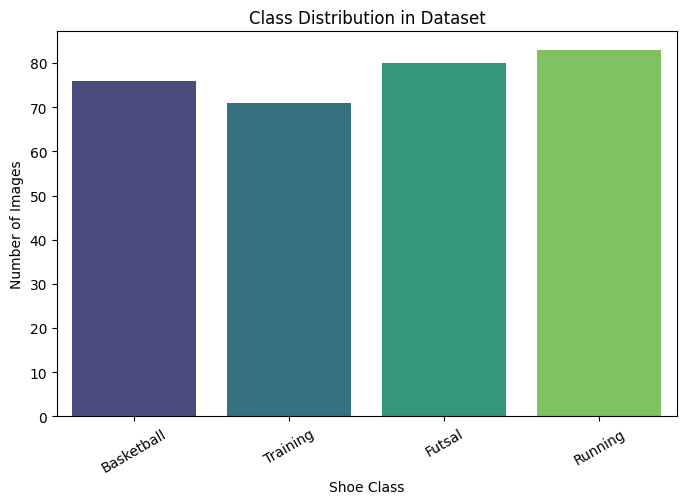

In [10]:
# ตรวจสอบความไม่สมดุลของ dataset (Imbalance Analysis)

import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=df_counts["Class"], y=df_counts["Number of Images"], palette="viridis")
plt.xlabel("Shoe Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Dataset")
plt.xticks(rotation=30)
plt.show()


In [11]:
min_class = min(class_counts.values())  # จำนวนภาพในคลาสที่น้อยที่สุด
max_class = max(class_counts.values())  # จำนวนภาพในคลาสที่มากที่สุด
print(f"Min class size: {min_class}, Max class size: {max_class}")

imbalance_ratio = max_class / min_class
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 1.5:  # ถ้ามากกว่า 1.5 แสดงว่า dataset อาจไม่สมดุล
    print("⚠️ Warning: Dataset is imbalanced. Consider using data augmentation or resampling techniques.")
else:
    print("✅ Dataset looks balanced.")


Min class size: 71, Max class size: 83
Imbalance Ratio: 1.17
✅ Dataset looks balanced.


In [ ]:
#Part 2: Data Preparation

In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# กำหนดค่าขนาดภาพมาตรฐาน
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# ฟังก์ชันเตรียมข้อมูล (resize + normalize)
def preprocess_image(image):
    image = tf.image.resize(image, IMAGE_SIZE)  # Resize รูปเป็น 224x224
    image = image / 255.0  # Normalize ค่าให้เป็นช่วง [0,1]
    return image


In [13]:
# กำหนดพาธของ dataset
DATASET_PATH = "/content/dataset"

# ใช้ ImageDataGenerator แบ่งชุดข้อมูล
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.20)  # 80% train, 20% validation

# Train set (60%)
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'  # 80% จาก train set
)

# Validation set (20%)
val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'  # 20% จาก train set
)

# Test set (20%) → ใช้โฟลเดอร์แยก
TEST_PATH = "/content/Test"
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# แสดงจำนวนรูปในแต่ละชุด
print(f"✅ Train set size: {train_generator.samples} images")
print(f"✅ Validation set size: {val_generator.samples} images")
print(f"✅ Test set size: {test_generator.samples} images")


Found 247 images belonging to 4 classes.
Found 61 images belonging to 4 classes.
Found 80 images belonging to 4 classes.
✅ Train set size: 247 images
✅ Validation set size: 61 images
✅ Test set size: 80 images


In [17]:
# 3. Data Augmentation (เสริมความหลากหลายให้ข้อมูล)

# Augmentation สำหรับ Train Set
train_aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,         # หมุนภาพไม่เกิน 40 องศา (เพิ่มขึ้นเล็กน้อย)
    width_shift_range=0.15,    # ขยับภาพแนวนอนไม่เกิน 25%
    height_shift_range=0.15,   # ขยับภาพแนวตั้งไม่เกิน 25%
    shear_range=0.2,           # เพิ่มการบิดภาพเล็กน้อย (shear)
    zoom_range=0.2,            # ซูมเข้า-ออกไม่เกิน 30% (เพิ่มขึ้น)
    brightness_range=[0.7, 1.3], # ปรับความสว่างระหว่าง 70% - 130%
    horizontal_flip=True,      # กลับด้านแนวนอน
    fill_mode='nearest',       # เติมส่วนที่ขาดหายไปของภาพ
    validation_split=0.20      # ใช้ validation set 20%
)

# สร้าง Train Set ใหม่ที่มี Augmentation
train_aug_generator = train_aug_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'  # 80% จาก train set
)


Found 247 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


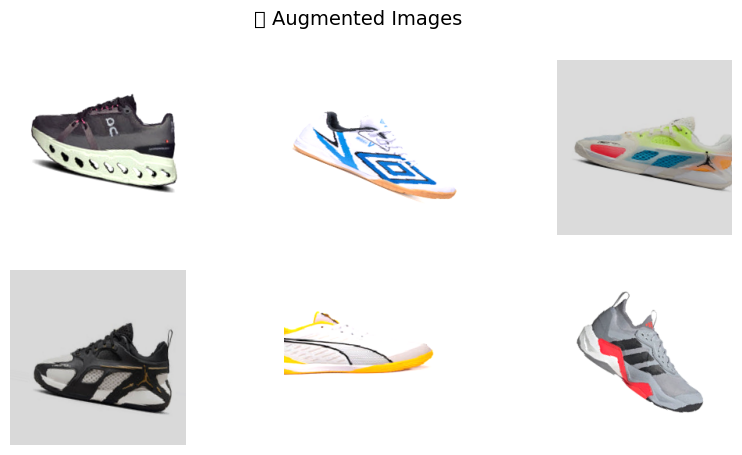

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ดึงรูปจาก Train Generator ที่มี Augmentation
sample_images, _ = next(train_aug_generator)

# แสดง 6 ตัวอย่าง
plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(sample_images[i])
    plt.axis("off")
plt.suptitle("🔍 Augmented Images", fontsize=14)
plt.show()


In [ ]:
# 3. Model architecture

21834768/21834768 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step
🔍 Found classes: ['Basketball', 'Futsal', 'Running', 'Training']
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
📸 EfficientNetB0 - Basketball: image_80.jpg -> 🔍 Predicted: running_shoe
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
📸 MobileNetV2 - Basketball: image_80.jpg -> 🔍 Predicted: running_shoe
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
📸 ResNet50 - Basketball: image_80.jpg -> 🔍 Predicted: running_shoe
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
📸 VGG16 - Basketball: image_80.jpg -> 🔍 Predicted: running_shoe
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
📸 EfficientNetB0 - Futsal: image_83.jpg -> 🔍 Predicted: running_shoe
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
📸 MobileNetV2 - Futsal: image_83.jpg -> 🔍 Predicted: running_shoe
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
📸 ResNet50 - F

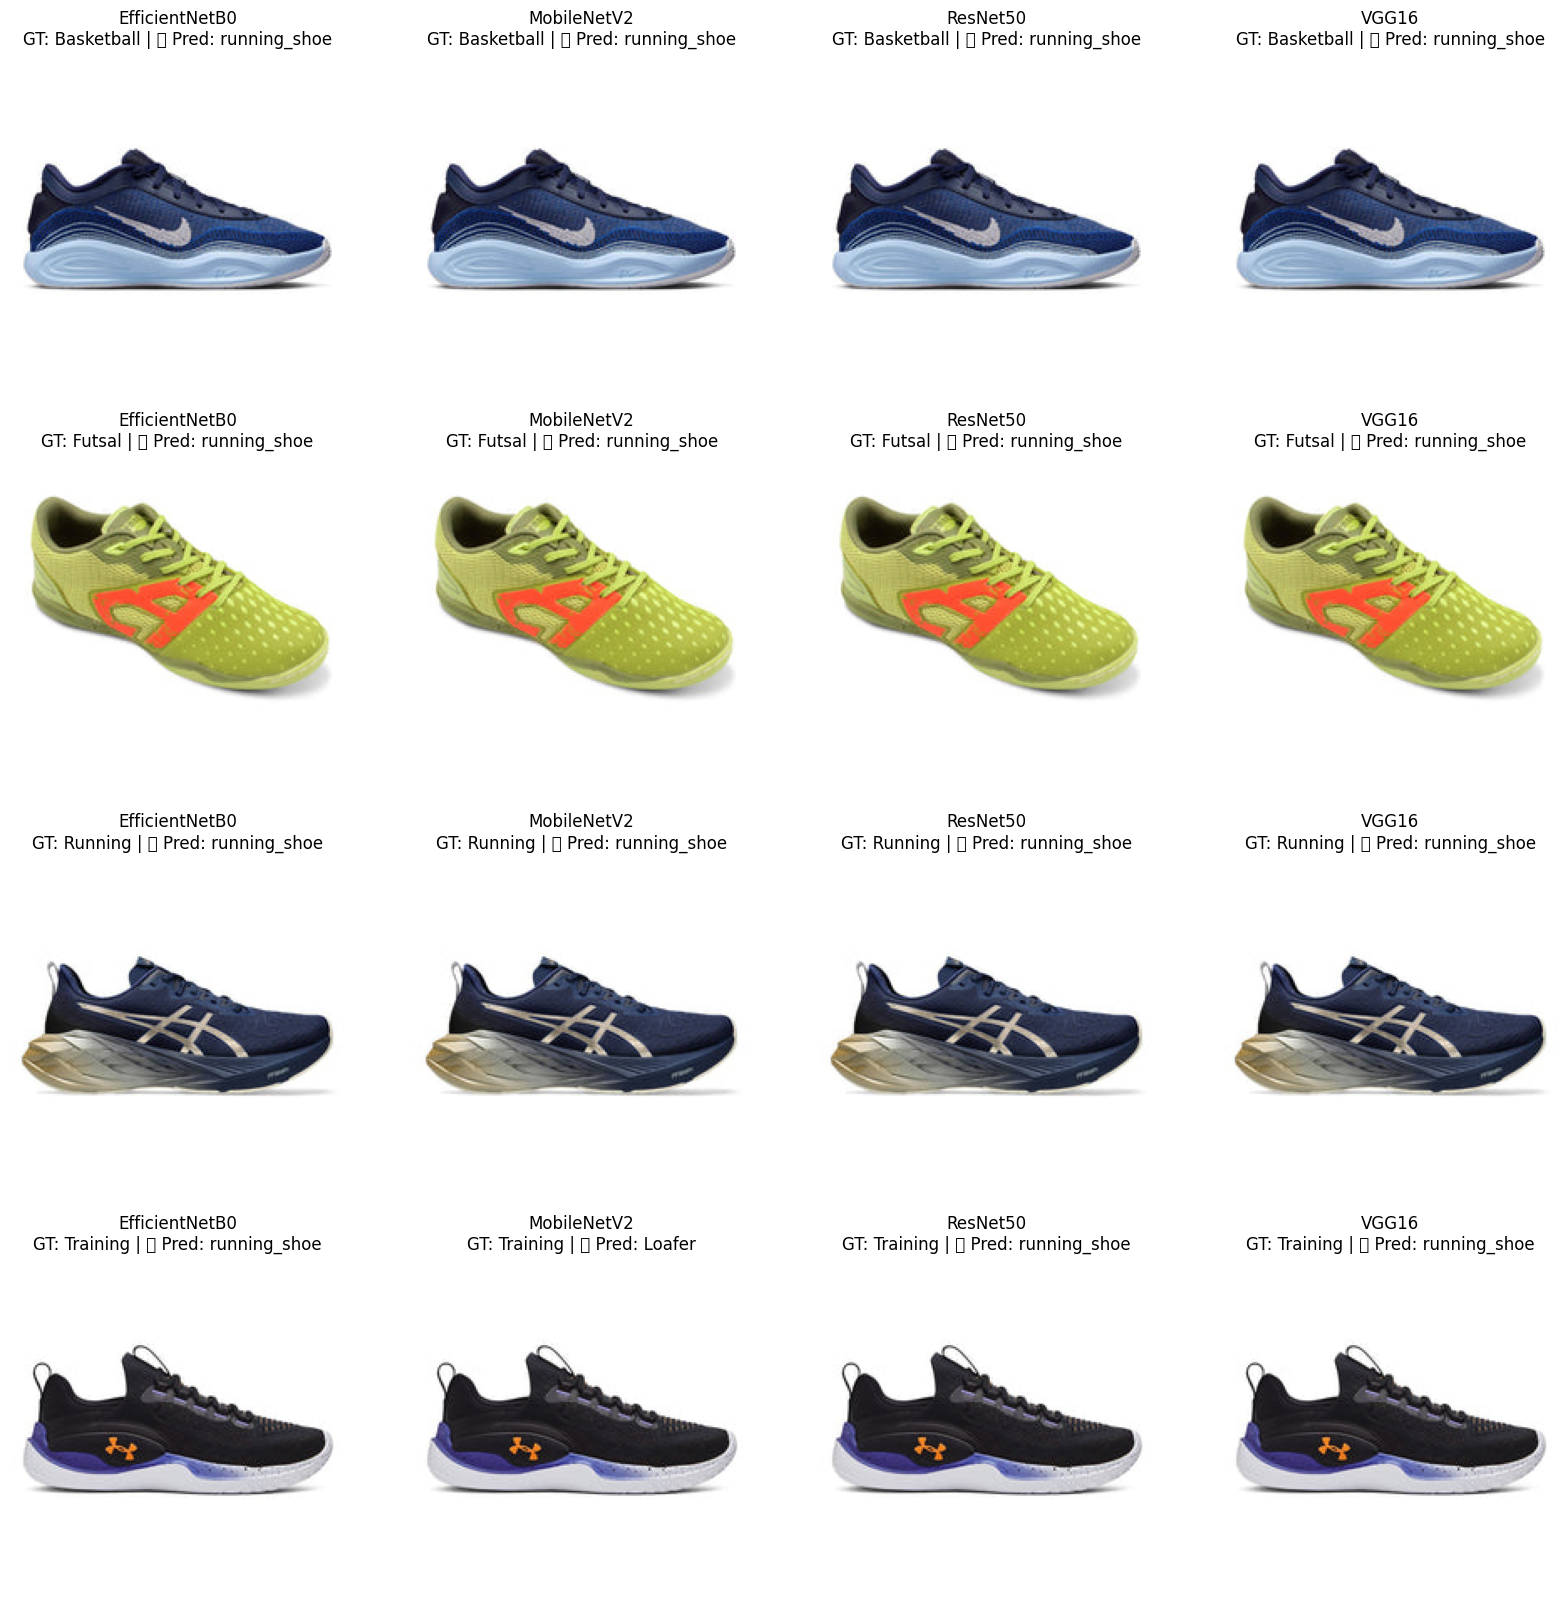

,Model,GT Class,Image,Predicted
0,EfficientNetB0,Basketball,image_80.jpg,running_shoe
1,MobileNetV2,Basketball,image_80.jpg,running_shoe
2,ResNet50,Basketball,image_80.jpg,running_shoe
3,VGG16,Basketball,image_80.jpg,running_shoe
4,EfficientNetB0,Futsal,image_83.jpg,running_shoe
5,MobileNetV2,Futsal,image_83.jpg,running_shoe
6,ResNet50,Futsal,image_83.jpg,running_shoe
7,VGG16,Futsal,image_83.jpg,running_shoe
8,EfficientNetB0,Running,image_95.jpg,running_shoe
9,MobileNetV2,Running,image_95.jpg,running_shoe


In [16]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import pandas as pd
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50, VGG16
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess



# ------------------------------
# โหลดโมเดลพรีเทรน (ยังไม่ทำ Fine-tune)
# ------------------------------
models = {
    "EfficientNetB0": EfficientNetB0(weights="imagenet"),
    "MobileNetV2": MobileNetV2(weights="imagenet"),
    "ResNet50": ResNet50(weights="imagenet"),
    "VGG16": VGG16(weights="imagenet"),
}

# ฟังก์ชัน Preprocessing ตามโมเดลที่เลือก
preprocess_functions = {
    "EfficientNetB0": efficientnet_preprocess,
    "MobileNetV2": mobilenet_preprocess,
    "ResNet50": resnet_preprocess,
    "VGG16": vgg_preprocess,
}

# ------------------------------
# กำหนด path ของโฟลเดอร์ที่เก็บภาพทดสอบ
# ------------------------------
test_folder = "/content/Test"

# อ่านรายชื่อคลาสที่มีอยู่ในโฟลเดอร์
classes = sorted(os.listdir(test_folder))
print(f"🔍 Found classes: {classes}")

# ------------------------------
# ฟังก์ชันสุ่มเลือกรูปจากแต่ละคลาส
# ------------------------------
def get_random_image(class_name):
    class_path = os.path.join(test_folder, class_name)
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if not image_files:
        return None, None
    random_image = random.choice(image_files)
    return os.path.join(class_path, random_image), random_image

# ------------------------------
# ฟังก์ชันทำนาย class โดยโมเดลพรีเทรน
# ------------------------------
def predict_class(image_path, model_name):
    model = models[model_name]
    preprocess_func = preprocess_functions[model_name]

    try:
        img = cv2.imread(image_path)
        if img is None:
            return "Error: Image not found"

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        img = preprocess_func(img)
        img = np.expand_dims(img, axis=0)

        preds = model.predict(img)
        decoded_preds = tf.keras.applications.imagenet_utils.decode_predictions(preds, top=1)[0][0][1]
        return decoded_preds
    except Exception as e:
        return f"Error: {str(e)}"

# ------------------------------
# ทดสอบโมเดลโดยไม่ fine-tune และเก็บผลลัพธ์ใน DataFrame
# ------------------------------
results = []
fig, axes = plt.subplots(len(classes), len(models), figsize=(20, 5 * len(classes)))

for i, class_name in enumerate(classes):
    image_path, image_name = get_random_image(class_name)
    if image_path and os.path.exists(image_path):
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        for j, model_name in enumerate(models.keys()):
            pred_class = predict_class(image_path, model_name)

            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{model_name}\nGT: {class_name} | 🔍 Pred: {pred_class}")
            axes[i, j].axis("off")

            # บันทึกผลลัพธ์เป็นตาราง
            results.append({"Model": model_name, "GT Class": class_name, "Image": image_name, "Predicted": pred_class})
            print(f"📸 {model_name} - {class_name}: {image_name} -> 🔍 Predicted: {pred_class}")
    else:
        for j in range(len(models)):
            axes[i, j].text(0.5, 0.5, "No Image", fontsize=12, ha='center')
            axes[i, j].set_title(classes[i])
            axes[i, j].axis("off")

plt.show()

# ------------------------------
# แสดงผลเป็น DataFrame
# ------------------------------
df_results = pd.DataFrame(results)
from google.colab import data_table
data_table.DataTable(df_results)


In [ ]:
# 4.Training method

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2  # ใช้ L2 Regularization

# ฟังก์ชันสร้างโมเดล (เลือก Backbone และกำหนด output ใหม่)
def create_model(base_model_name, num_classes=4):
    if base_model_name == "EfficientNetB0":
        base_model = tf.keras.applications.EfficientNetB0(weights="imagenet", include_top=False)
    elif base_model_name == "MobileNetV2":
        base_model = tf.keras.applications.MobileNetV2(weights="imagenet", include_top=False)
    elif base_model_name == "ResNet50":
        base_model = tf.keras.applications.ResNet50(weights="imagenet", include_top=False)
    elif base_model_name == "VGG16":
        base_model = tf.keras.applications.VGG16(weights="imagenet", include_top=False)
    else:
        raise ValueError("Invalid model name")

    # Freeze น้ำหนักของ Backbone
    base_model.trainable = False

    # เพิ่ม Fully Connected Layer ใหม่ พร้อม L2 Regularization
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation="relu", kernel_regularizer=l2(0.01))(x)  # L2 Regularization
    x = Dropout(0.6)(x)  # Dropout ช่วยลด Overfitting
    output = Dense(num_classes, activation="softmax")(x)

    # รวม Backbone + Fully Connected Layers
    model = Model(inputs=base_model.input, outputs=output)
    return model

# ทดสอบสร้างโมเดล
model = create_model("MobileNetV2")
model.summary()  # ตรวจสอบโครงสร้าง


<ipython-input-2-fabd6d72241d>:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(weights="imagenet", include_top=False)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, None, None, 3)  │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, None, None, 32) │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, None, None, 32) │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, None, None, 32) │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, None, None, 32) │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, None, None, 32) │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, None, None, 32) │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, None, None, 16) │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, None, None, 16) │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, None, None, 96) │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, None, None, 96) │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, None, None, 96) │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, None, None, 96) │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, None, None, 96) │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,915,908 (11.12 MB)

 Trainable params: 657,924 (2.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# กำหนด Optimizer, Loss Function และ Metrics
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)  # 🔧 Learning Rate เล็กเพื่อให้เรียนรู้ดีขึ้น
loss_fn = tf.keras.losses.CategoricalCrossentropy()
metrics = ["accuracy"]

# คอมไพล์โมเดล
model.compile(optimizer=optimizer, loss=loss_fn, metrics=metrics)



wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: art-tra-ctw (napateek-nida-business-school) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING When using `save_best_only`, ensure that the `filepath` argument contains formatting placeholders like `{epoch:02d}` or `{batch:02d}`. This ensures correct interpretation of the logged artifacts.


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.3563 - loss: 9.0634 - val_accuracy: 0.2787 - val_loss: 8.5530
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.2692 - loss: 8.7066 - val_accuracy: 0.3607 - val_loss: 8.3503
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.3712 - loss: 8.4319 - val_accuracy: 0.4262 - val_loss: 8.1111
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.4110 - loss: 8.2109 - val_accuracy: 0.5082 - val_loss: 7.9173
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.4517 - loss: 7.8869 - val_accuracy: 0.5246 - val_loss: 7.7369
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.6402 - loss: 7.5008 - val_accuracy: 0.5246 - val_loss: 7.5728
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.5922 - loss: 7.4432 - val_accuracy: 0.5410 - val_loss: 7.4256
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.6259 - loss: 7.2284 - val_accuracy: 0.5738 - val_loss: 7.2818
Epoch

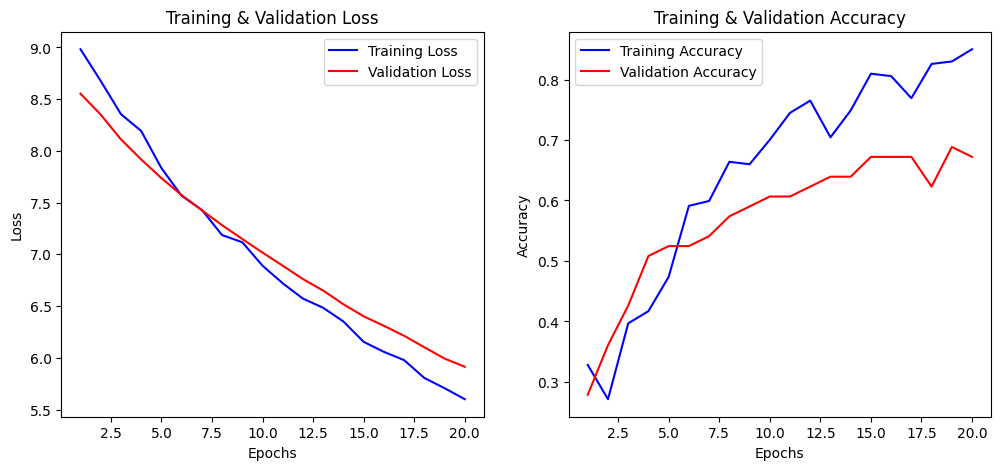

In [ ]:
import matplotlib.pyplot as plt
import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint

# ✅ เริ่ม WandB ด้วยชื่อ entity ที่ถูกต้อง
wandb.init(project="Shoe-Classification", entity="napateek-nida-business-school", config={
    "learning_rate": 0.0001,
    "epochs": 30,
    "batch_size": 32
})

# ตั้งค่าคอนฟิกจาก WandB
config = wandb.config

# ✅ ใช้ Callback ที่ใหม่กว่า
wandb_callbacks = [
    WandbMetricsLogger(),  # 📊 Log Metrics เช่น loss, accuracy
    WandbModelCheckpoint(filepath="best_model.keras", monitor="val_loss", save_best_only=True)  # ✅ Save Best Model
]

# ✅ Train Model พร้อม Callback ของ WandB
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs= 20,
    batch_size=config.batch_size,
    callbacks=wandb_callbacks  # ✅ ใช้ Callback ที่ถูกต้อง
)

# --------------------------
# ✅ แสดงผลลัพธ์ของการ Training
# --------------------------

# ดึงค่า loss และ accuracy
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

# ✅ Plot กราฟ Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# ✅ Plot กราฟ Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# ✅ แสดงผลลัพธ์
plt.show()


In [ ]:
import pandas as pd

# แสดงจำนวนรูปภาพในแต่ละชุด
df_summary = pd.DataFrame({
    "Dataset Split": ["Train", "Validation", "Test"],
    "Number of Images": [train_generator.samples, val_generator.samples, test_generator.samples]
})

print(df_summary)

  Dataset Split  Number of Images
0         Train               247
1    Validation                61
2          Test                80


In [ ]:
# 5. Evaluation metrics

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step
              precision    recall  f1-score   support

  Basketball       0.71      0.75      0.73        20
      Futsal       0.86      0.90      0.88        20
     Running       0.65      0.75      0.70        20
    Training       0.80      0.60      0.69        20

    accuracy                           0.75        80
   macro avg       0.76      0.75      0.75        80
weighted avg       0.76      0.75      0.75        80



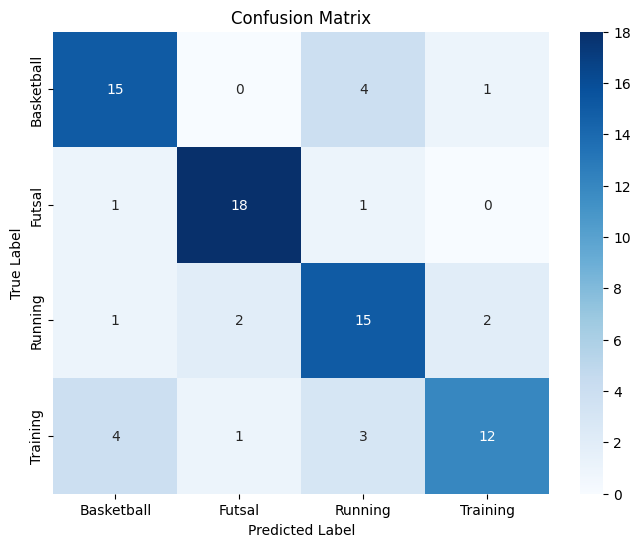

In [ ]:
# โค้ดสำหรับวัดผล Accuracy, Precision, Recall และ F1-score

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ ใช้โมเดลทำนายบน Test Set
y_true = test_generator.classes  # Ground Truth Labels
y_pred_probs = model.predict(test_generator)  # Prediction Probabilities
y_pred = np.argmax(y_pred_probs, axis=1)  # แปลงผลลัพธ์เป็นคลาสที่โมเดลทำนาย

# ✅ แสดงรายงานผลลัพธ์ของแต่ละคลาส (Precision, Recall, F1-score)
class_labels = list(test_generator.class_indices.keys())  # รายชื่อคลาส
print(classification_report(y_true, y_pred, target_names=class_labels))

# ✅ แสดง Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# 6. Experimental results

In [28]:
#######################################################
# SECTION 1: Import Libraries & Global Settings
#######################################################
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    MobileNetV2, ResNet50, VGG16, EfficientNetB0
)
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import Callback

# ตั้งค่าแสดงผล Pandas ให้สวยขึ้น
pd.set_option("display.precision", 4)
pd.set_option("display.width", 1000)

#######################################################
# SECTION 2: Prepare Dataset (Data Generators)
#######################################################
DATASET_PATH = "/content/dataset"
TEST_PATH    = "/content/Test"
NUM_CLASSES  = 4

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

#######################################################
# SECTION 3: Callback สำหรับจับเวลาในแต่ละ Epoch
#######################################################
class TimeHistory(Callback):
    """
    Callback สำหรับจับเวลาในแต่ละ epoch
    """
    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.start_time
        self.epoch_times.append(elapsed)

#######################################################
# SECTION 4: Function สร้างโมเดล (With Fine-Tuning & L2 Regularization)
#######################################################
def create_model(model_name, num_classes=4, fine_tune=True):
    if model_name == "MobileNetV2":
        base_model = MobileNetV2(weights="imagenet", include_top=False)
    elif model_name == "ResNet50":
        base_model = ResNet50(weights="imagenet", include_top=False)
    elif model_name == "EfficientNetB0":
        base_model = EfficientNetB0(weights="imagenet", include_top=False)
    elif model_name == "VGG16":
        base_model = VGG16(weights="imagenet", include_top=False)
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    # Fine-tuning: Unfreeze Layers บางส่วน

    # ✅ Freeze ทุก Layer (ไม่ให้เรียนรู้ต่อ)
    base_model.trainable = False  # ❌ ไม่ให้ Backbone อัปเดตน้ำหนัก

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation="relu", kernel_regularizer=l2(0.001))(x)  # ✅ L2 Regularization
    x = Dropout(0.1)(x)
    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

#######################################################
# SECTION 5: Train & Fine-Tune Models
#######################################################
model_names = ["EfficientNetB0", "MobileNetV2", "ResNet50", "VGG16"]
num_runs = 5
num_epochs = 25
learning_rate = 1e-4

all_results = {model: [] for model in model_names}

for model_name in model_names:
    for run in range(num_runs):
        print(f"\n===== Training Model: {model_name} (Run {run+1}) =====")
        tf.keras.backend.clear_session()

        model = create_model(model_name, num_classes=NUM_CLASSES, fine_tune=True)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )

        time_callback = TimeHistory()

        history = model.fit(
            train_generator,
            validation_data=val_generator,
            epochs=num_epochs,
            callbacks=[time_callback],
            verbose=1
        )

        epoch_times = time_callback.epoch_times
        avg_time_per_epoch = np.mean(epoch_times)

        test_start = time.time()
        y_pred = model.predict(test_generator)
        test_time = time.time() - test_start

        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true = test_generator.classes

        report = classification_report(y_true, y_pred_classes, output_dict=True)
        accuracy = report["accuracy"]
        precision = np.mean([report[str(cls)]["precision"] for cls in np.unique(y_true)])
        recall    = np.mean([report[str(cls)]["recall"] for cls in np.unique(y_true)])
        f1_score  = np.mean([report[str(cls)]["f1-score"] for cls in np.unique(y_true)])

        all_results[model_name].append({
            "history": history.history,
            "avg_epoch_time_sec": avg_time_per_epoch,
            "test_inference_time_sec": test_time,
            "y_true": y_true,
            "y_pred_classes": y_pred_classes,
            "metrics": {
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1_score": f1_score
            }
        })




Found 247 images belonging to 4 classes.
Found 61 images belonging to 4 classes.
Found 80 images belonging to 4 classes.

===== Training Model: EfficientNetB0 (Run 1) =====
Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.2720 - loss: 2.1309 - val_accuracy: 0.2623 - val_loss: 2.1132
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.1797 - loss: 2.1136 - val_accuracy: 0.2295 - val_loss: 2.0966
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.2050 - loss: 2.1071 - val_accuracy: 0.2623 - val_loss: 2.0827
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.1947 - loss: 2.0873 - val_accuracy: 0.2623 - val_loss: 2.0727
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.2227 - loss: 2.0889 - val_accuracy: 0.2623 - val_loss: 2.0623
Epoch 6/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.3259 - loss: 2.0494 - val_accuracy: 0.2623 - val_loss: 2.0505
Epoch 7/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.2736 - loss: 2.0508 - val_accuracy: 0.2623 - val_loss: 2.0426
Epoch 8/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.2129 - loss: 2.0486 - val_accuracy: 0.2623 - val_loss: 2.0343
Epoch 9/25
8

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.2410 - loss: 2.1315 - val_accuracy: 0.2623 - val_loss: 2.1040
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.2930 - loss: 2.1059 - val_accuracy: 0.2459 - val_loss: 2.0933
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.2711 - loss: 2.0926 - val_accuracy: 0.2623 - val_loss: 2.0806
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.2327 - loss: 2.0769 - val_accuracy: 0.2623 - val_loss: 2.0675
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.2160 - loss: 2.0688 - val_accuracy: 0.2623 - val_loss: 2.0572
Epoch 6/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.2592 - loss: 2.0648 - val_accuracy: 0.2623 - val_loss: 2.0436
Epoch 7/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.2339 - loss: 2.0484 - val_accuracy: 0.2623 - val_loss: 2.0318
Epoch 8/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.2134 - loss: 2.0286 - val_accuracy: 0.2623 - val_loss: 2.0236
E

...

Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.2858 - loss: 2.3276 - val_accuracy: 0.3115 - val_loss: 2.1809
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.2698 - loss: 2.1760 - val_accuracy: 0.3934 - val_loss: 2.1316
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.2657 - loss: 2.1133 - val_accuracy: 0.2951 - val_loss: 2.1023
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.2651 - loss: 2.1307 - val_accuracy: 0.2459 - val_loss: 2.0677
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.2220 - loss: 2.1086 - val_accuracy: 0.3279 - val_loss: 2.0340
Epoch 6/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.2791 - loss: 2.0609 - val_accuracy: 0.3279 - val_loss: 2.0057
Epoch 7/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.2824 - loss: 2.0253 - val_accuracy: 0.3443 - val_loss: 1.9792
Epoch 8/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.2490 - loss: 2.0167 - val_accuracy: 0.3115 - val_loss: 1

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.2546 - loss: 2.2548 - val_accuracy: 0.2623 - val_loss: 2.1888
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.2409 - loss: 2.2199 - val_accuracy: 0.2623 - val_loss: 2.1610
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.2578 - loss: 2.1664 - val_accuracy: 0.1311 - val_loss: 2.1100
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.2634 - loss: 2.1277 - val_accuracy: 0.2787 - val_loss: 2.0799
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.2308 - loss: 2.1107 - val_accuracy: 0.2623 - val_loss: 2.0489
Epoch 6/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.2850 - loss: 2.0321 - val_accuracy: 0.2787 - val_loss: 2.0167
Epoch 7/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.2652 - loss: 2.0173 - val_accuracy: 0.2295 - val_loss: 1.9902
Epoch 8/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.3165 - loss: 1.9714 - val_accuracy: 0.1803 - val_loss: 1

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 517ms/step - accuracy: 0.2754 - loss: 2.0009 - val_accuracy: 0.2623 - val_loss: 1.9123
Epoch 2/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - accuracy: 0.2244 - loss: 1.9047 - val_accuracy: 0.2459 - val_loss: 1.8833
Epoch 3/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - accuracy: 0.2958 - loss: 1.8721 - val_accuracy: 0.2623 - val_loss: 1.8664
Epoch 4/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - accuracy: 0.3166 - loss: 1.8427 - val_accuracy: 0.3115 - val_loss: 1.8449
Epoch 5/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - accuracy: 0.4628 - loss: 1.8068 - val_accuracy: 0.3115 - val_loss: 1.8269
Epoch 6/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 219ms/step - accuracy: 0.3757 - loss: 1.7912 - val_accuracy: 0.3443 - val_loss: 1.8100
Epoch 7/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - accuracy: 0.3969 - loss: 1.7767 - val_accuracy: 0.4918 - val_loss: 1.7912
Epoch 8/25
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - accuracy: 0.4350 - loss: 1.7588 - val_accuracy: 0.4426 - val_loss:

In [29]:
# ✅ สร้างลิสต์เพื่อเก็บผลลัพธ์
df_results_list = []

# ✅ Loop ผ่านโมเดลแต่ละตัว
for model_name, runs in all_results.items():
    df_results_list.append({
        "Model": model_name,
        "Accuracy (mean ± SD)": f"{np.mean([r['metrics']['accuracy'] for r in runs]):.4f} ± {np.std([r['metrics']['accuracy'] for r in runs]):.4f}",
        "Precision (mean ± SD)": f"{np.mean([r['metrics']['precision'] for r in runs]):.4f} ± {np.std([r['metrics']['precision'] for r in runs]):.4f}",
        "Recall (mean ± SD)": f"{np.mean([r['metrics']['recall'] for r in runs]):.4f} ± {np.std([r['metrics']['recall'] for r in runs]):.4f}",
        "F1-score (mean ± SD)": f"{np.mean([r['metrics']['f1_score'] for r in runs]):.4f} ± {np.std([r['metrics']['f1_score'] for r in runs]):.4f}",
    })

# ✅ แปลงลิสต์เป็น DataFrame ด้วย `pd.DataFrame()`
df_results = pd.DataFrame(df_results_list)

# ✅ แสดงผลลัพธ์
print("\n========== Evaluation Results ==========")
print(df_results)

# ✅ บันทึกผลเป็น CSV
df_results.to_csv("evaluation_metrics.csv", index=False)
print("✅ บันทึกผลเป็น CSV => 'evaluation_metrics.csv'")




========== Evaluation Results ==========
            Model Accuracy (mean ± SD) Precision (mean ± SD) Recall (mean ± SD) F1-score (mean ± SD)
0  EfficientNetB0      0.2500 ± 0.0000       0.0625 ± 0.0000    0.2500 ± 0.0000      0.1000 ± 0.0000
1     MobileNetV2      0.7600 ± 0.0166       0.7645 ± 0.0183    0.7600 ± 0.0166      0.7570 ± 0.0166
2        ResNet50      0.4400 ± 0.0483       0.3769 ± 0.0546    0.4400 ± 0.0483      0.3862 ± 0.0494
3           VGG16      0.6100 ± 0.0184       0.6068 ± 0.0259    0.6100 ± 0.0184      0.5711 ± 0.0297
✅ บันทึกผลเป็น CSV => 'evaluation_metrics.csv'


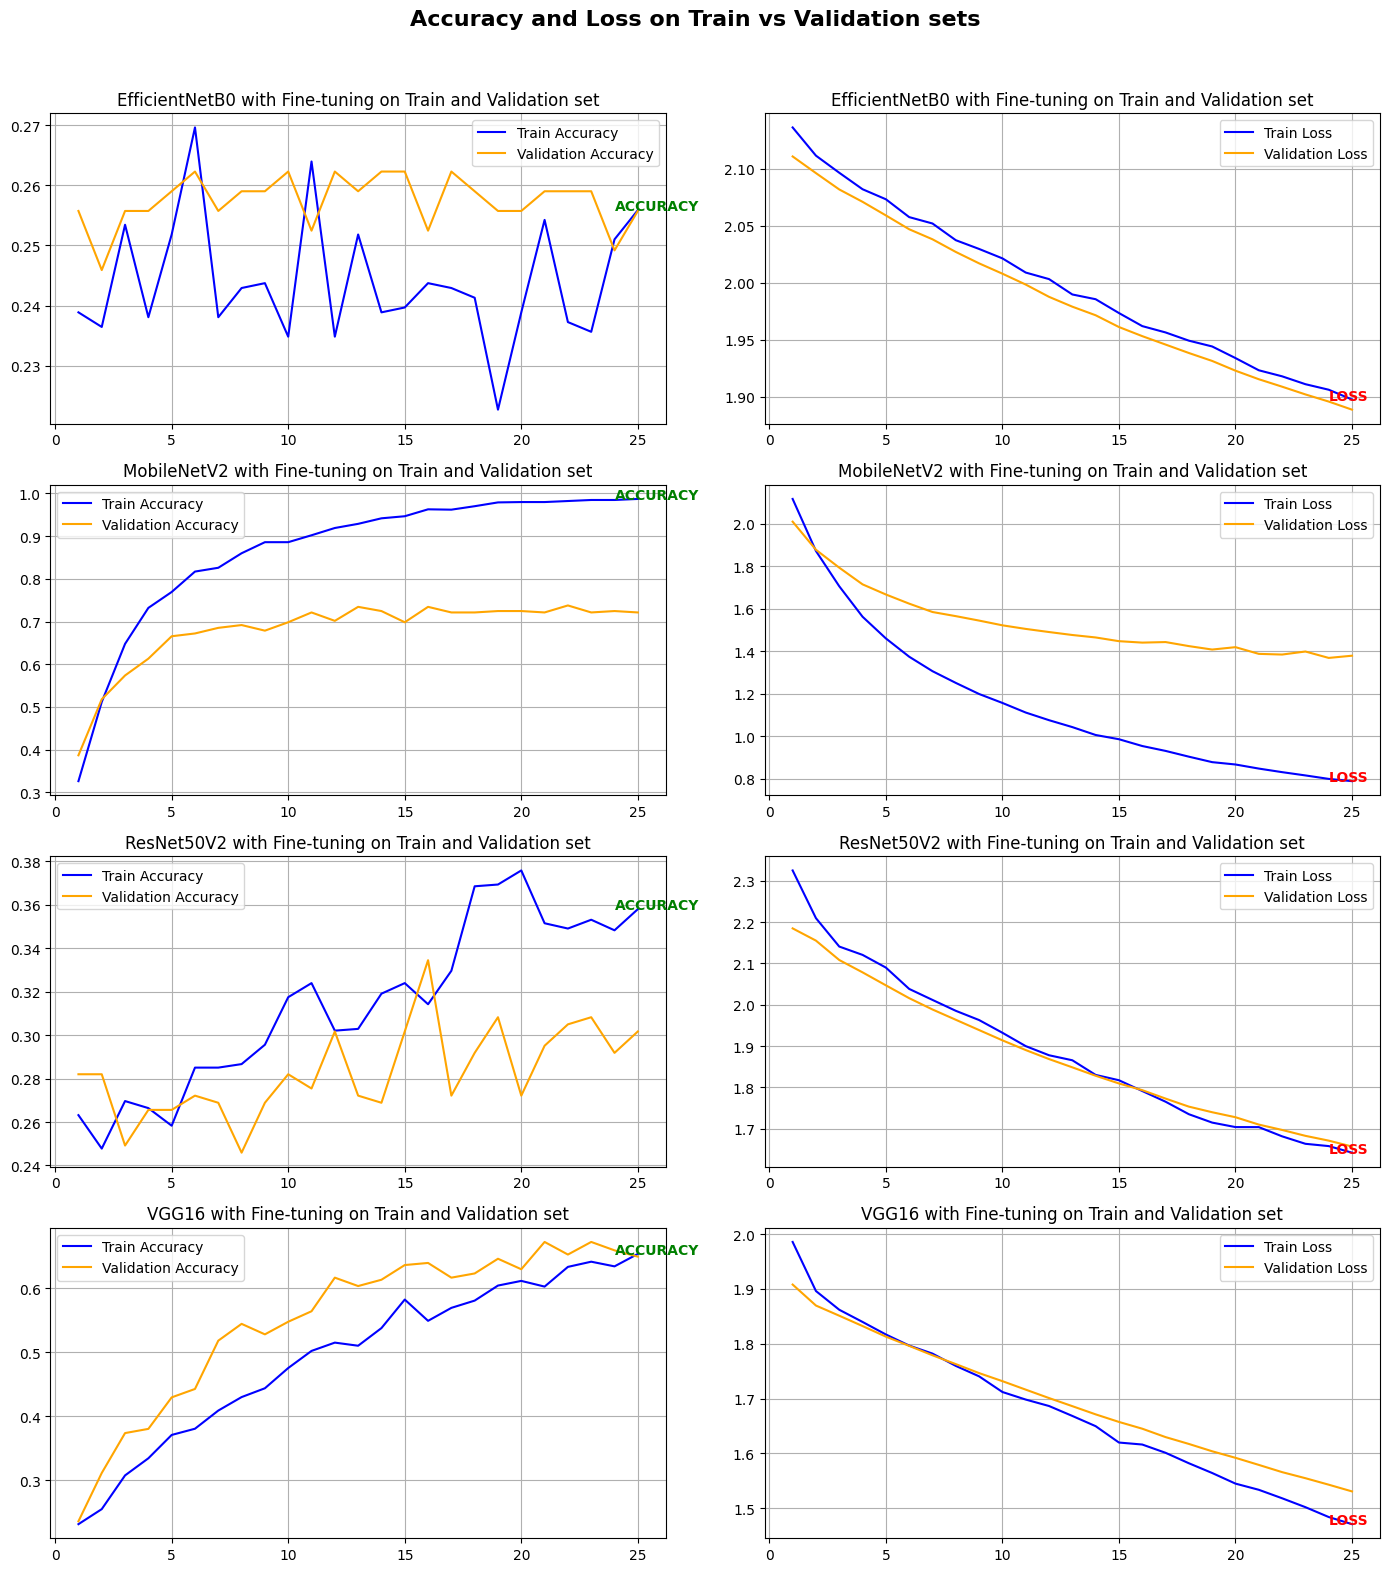

In [30]:
import matplotlib.pyplot as plt

# ✅ สร้างกราฟ Accuracy & Loss
fig, axes = plt.subplots(4, 2, figsize=(14, 16))  # 4 โมเดล x 2 กราฟ (Accuracy, Loss)
fig.suptitle("Accuracy and Loss on Train vs Validation sets", fontsize=16, fontweight="bold")

# ✅ Map ชื่อโมเดลให้ตรงกับชื่อที่ใช้ใน dictionary
model_titles = {
    "VGG16": "VGG16",
    "Xception": "Xception",
    "ResNet50": "ResNet50V2",
    "InceptionV3": "InceptionV3",
    "EfficientNetB0": "EfficientNetB0"  # ✅ เพิ่ม EfficientNetB0 เพื่อป้องกัน KeyError
}

# ✅ Loop วาดกราฟแต่ละโมเดล
for i, model_name in enumerate(all_results.keys()):
    runs = all_results[model_name]

    # ✅ ดึงค่า Accuracy และ Loss ของแต่ละ epoch จากทุกการรัน
    train_acc_all = [run["history"]["accuracy"] for run in runs]
    val_acc_all = [run["history"]["val_accuracy"] for run in runs]
    train_loss_all = [run["history"]["loss"] for run in runs]
    val_loss_all = [run["history"]["val_loss"] for run in runs]

    # ✅ คำนวณค่า Mean ของแต่ละ epoch
    train_acc = np.mean(train_acc_all, axis=0)
    val_acc = np.mean(val_acc_all, axis=0)
    train_loss = np.mean(train_loss_all, axis=0)
    val_loss = np.mean(val_loss_all, axis=0)

    epochs = range(1, len(train_acc) + 1)

    # ✅ Plot Accuracy
    axes[i, 0].plot(epochs, train_acc, 'b-', label="Train Accuracy")
    axes[i, 0].plot(epochs, val_acc, 'orange', label="Validation Accuracy")
    axes[i, 0].set_title(f"{model_titles.get(model_name, model_name)} with Fine-tuning on Train and Validation set", fontsize=12)  # ✅ ใช้ .get() แทนเพื่อป้องกัน KeyError
    axes[i, 0].legend()
    axes[i, 0].grid(True)
    axes[i, 0].text(len(epochs)-1, train_acc[-1], "ACCURACY", color="green", fontsize=10, fontweight="bold")

    # ✅ Plot Loss
    axes[i, 1].plot(epochs, train_loss, 'b-', label="Train Loss")
    axes[i, 1].plot(epochs, val_loss, 'orange', label="Validation Loss")
    axes[i, 1].set_title(f"{model_titles.get(model_name, model_name)} with Fine-tuning on Train and Validation set", fontsize=12)  # ✅ ใช้ .get() เช่นกัน
    axes[i, 1].legend()
    axes[i, 1].grid(True)
    axes[i, 1].text(len(epochs)-1, train_loss[-1], "LOSS", color="red", fontsize=10, fontweight="bold")

# ✅ ปรับ layout ให้พอดี
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



🔹 Classification Report: EfficientNetB0
              precision    recall  f1-score   support

  Basketball       0.00      0.00      0.00        20
      Futsal       0.00      0.00      0.00        20
     Running       0.25      1.00      0.40        20
    Training       0.00      0.00      0.00        20

    accuracy                           0.25        80
   macro avg       0.06      0.25      0.10        80
weighted avg       0.06      0.25      0.10        80


🔹 Classification Report: MobileNetV2
              precision    recall  f1-score   support

  Basketball       0.70      0.70      0.70        20
      Futsal       0.83      0.95      0.88        20
     Running       0.70      0.80      0.74        20
    Training       0.79      0.55      0.65        20

    accuracy                           0.75        80
   macro avg       0.75      0.75      0.74        80
weighted avg       0.75      0.75      0.74        80



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



🔹 Classification Report: ResNet50V2
              precision    recall  f1-score   support

  Basketball       0.55      0.60      0.57        20
      Futsal       0.62      0.65      0.63        20
     Running       0.38      0.60      0.46        20
    Training       0.40      0.10      0.16        20

    accuracy                           0.49        80
   macro avg       0.48      0.49      0.46        80
weighted avg       0.48      0.49      0.46        80


🔹 Classification Report: VGG16
              precision    recall  f1-score   support

  Basketball       0.53      0.50      0.51        20
      Futsal       0.95      1.00      0.98        20
     Running       0.52      0.75      0.61        20
    Training       0.45      0.25      0.32        20

    accuracy                           0.62        80
   macro avg       0.61      0.62      0.61        80
weighted avg       0.61      0.62      0.61        80



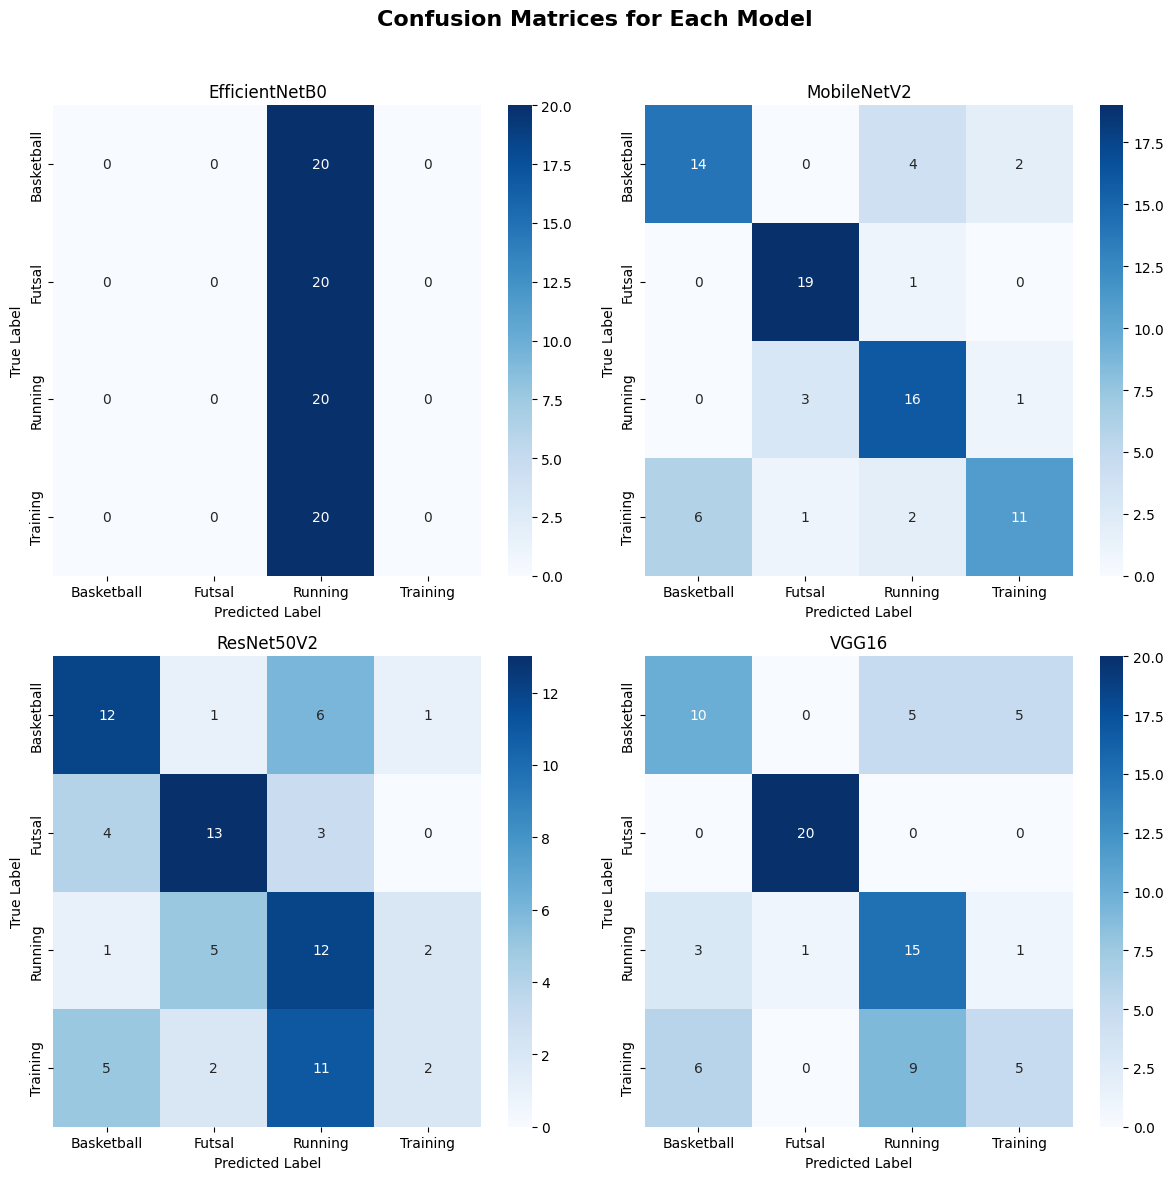

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ✅ ฟังก์ชันสำหรับแสดง Confusion Matrix และ Report ของแต่ละโมเดล
def plot_confusion_matrices(all_res_dict, class_names):
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))  # 2x2 grid สำหรับ 4 โมเดล
    fig.suptitle("Confusion Matrices for Each Model", fontsize=16, fontweight="bold")

    model_titles = {
        "EfficientNetB0": "EfficientNetB0",
        "MobileNetV2": "MobileNetV2",
        "ResNet50": "ResNet50V2",
        "VGG16": "VGG16"
    }

    for i, (model_name, runs) in enumerate(all_res_dict.items()):
        y_true = runs[0]["y_true"]
        y_pred_classes = runs[0]["y_pred_classes"]

        # ✅ สร้าง Confusion Matrix
        cm = confusion_matrix(y_true, y_pred_classes)

        # ✅ แสดง Classification Report
        print(f"\n🔹 Classification Report: {model_titles.get(model_name, model_name)}")
        print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=2))

        # ✅ พล็อต Confusion Matrix
        ax = axes[i // 2, i % 2]  # เลือกตำแหน่ง subplot
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=class_names, yticklabels=class_names)
        ax.set_title(f"{model_titles.get(model_name, model_name)}", fontsize=12)
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# ✅ ตั้งชื่อคลาสที่ใช้ใน dataset
class_names = ["Basketball", "Futsal", "Running", "Training"]

# ✅ เรียกใช้ฟังก์ชันเพื่อพล็อต
plot_confusion_matrices(all_results, class_names)


========= Runtime Comparison =========
Pre-training Models with Fine-tuning      GPU  Avg. time per epoch (sec)
                         MobileNetV2 Tesla T4                     1.1311
                            ResNet50 Tesla T4                     1.6119
                               VGG16 Tesla T4                     1.9124
                      EfficientNetB0 Tesla T4                     1.9687


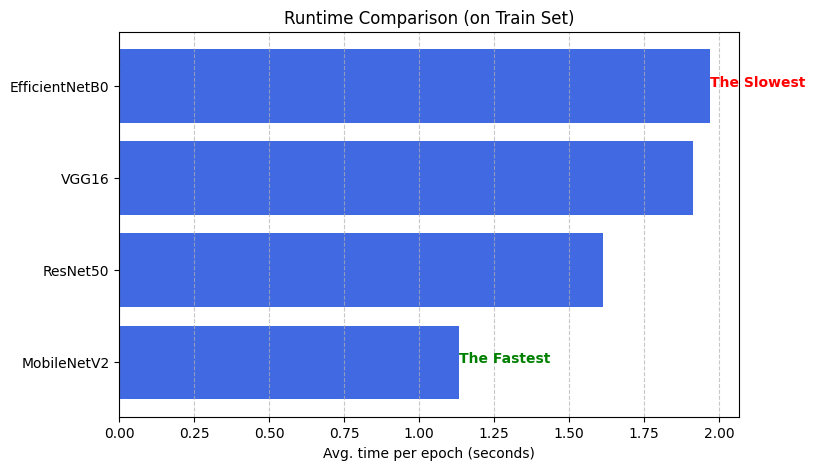

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ✅ ดึงข้อมูลเวลาเฉลี่ยต่อ epoch จาก all_results
runtime_data = []
for model_name, runs in all_results.items():
    avg_epoch_times = [run["avg_epoch_time_sec"] for run in runs]
    runtime_data.append([model_name, "Tesla T4", np.mean(avg_epoch_times)])

# ✅ แปลงข้อมูลเป็น DataFrame
df_runtime = pd.DataFrame(runtime_data, columns=["Pre-training Models with Fine-tuning", "GPU", "Avg. time per epoch (sec)"])
df_runtime = df_runtime.sort_values("Avg. time per epoch (sec)", ascending=True)  # ✅ เรียงลำดับจากเร็ว -> ช้า

# ✅ แสดงผลข้อมูลในรูปแบบตาราง
print("\n========= Runtime Comparison =========")
print(df_runtime.to_string(index=False))

# ✅ สร้างกราฟแท่งแสดงเวลาเฉลี่ยต่อ epoch
plt.figure(figsize=(8, 5))
plt.barh(df_runtime["Pre-training Models with Fine-tuning"], df_runtime["Avg. time per epoch (sec)"], color="royalblue")
plt.xlabel("Avg. time per epoch (seconds)")
plt.title("Runtime Comparison (on Train Set)")

# ✅ ไฮไลท์ fastest/slowest model
fastest_model = df_runtime.iloc[0]["Pre-training Models with Fine-tuning"]
slowest_model = df_runtime.iloc[-1]["Pre-training Models with Fine-tuning"]

plt.text(df_runtime["Avg. time per epoch (sec)"].max(), slowest_model, "The Slowest", color="red", fontweight="bold")
plt.text(df_runtime["Avg. time per epoch (sec)"].min(), fastest_model, "The Fastest", color="green", fontweight="bold")

plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


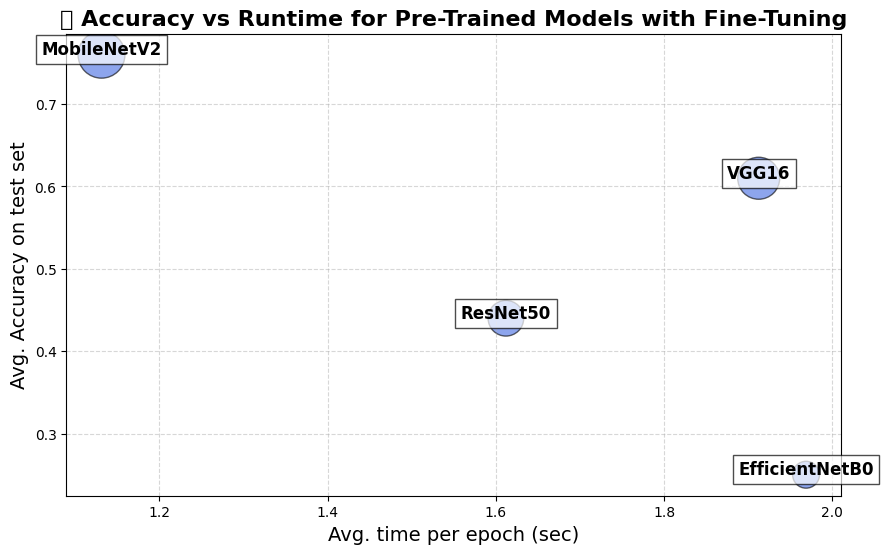

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ✅ ดึงค่าจริงจาก all_results
model_data = []
for model_name, runs in all_results.items():
    accuracies = [run["metrics"]["accuracy"] for run in runs]
    runtimes = [run["avg_epoch_time_sec"] for run in runs]

    # ✅ คำนวณค่าเฉลี่ยของ Accuracy และ Runtime
    avg_acc = np.mean(accuracies)
    avg_runtime = np.mean(runtimes)

    model_data.append([model_name, avg_acc, avg_runtime])

# ✅ แปลงเป็น DataFrame
df_bubble = pd.DataFrame(model_data, columns=["Model", "Accuracy", "Runtime"])

# ✅ Plot Bubble Chart
plt.figure(figsize=(10, 6))

# ขนาดของ Bubble ใช้ค่า Accuracy (เพื่อแสดงขนาดต่างกันชัดขึ้น)
bubble_size = df_bubble["Accuracy"] * 1500

# ✅ สร้างกราฟ Scatter Plot
plt.scatter(df_bubble["Runtime"], df_bubble["Accuracy"], s=bubble_size, color="royalblue", alpha=0.6, edgecolors="black")

# ✅ ใส่ชื่อโมเดลในแต่ละ Bubble (ปรับให้ใหญ่ขึ้นและอ่านง่ายขึ้น)
for i, row in df_bubble.iterrows():
    plt.text(row["Runtime"], row["Accuracy"], row["Model"], ha="center", fontsize=12, fontweight="bold", color="black", bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

# ✅ กำหนดค่าแกน
plt.xlabel("Avg. time per epoch (sec)", fontsize=14)
plt.ylabel("Avg. Accuracy on test set", fontsize=14)
plt.title("🏅 Accuracy vs Runtime for Pre-Trained Models with Fine-Tuning", fontsize=16, fontweight="bold")

# ✅ เปิด Grid และ Show Plot
plt.grid(alpha=0.5, linestyle="--")
plt.show()

In [ ]:
# 7. Discussion and conclusions

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
<ipython-input-34-fe1c9f92fb19>:82: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-34-fe1c9f92fb19>:82: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


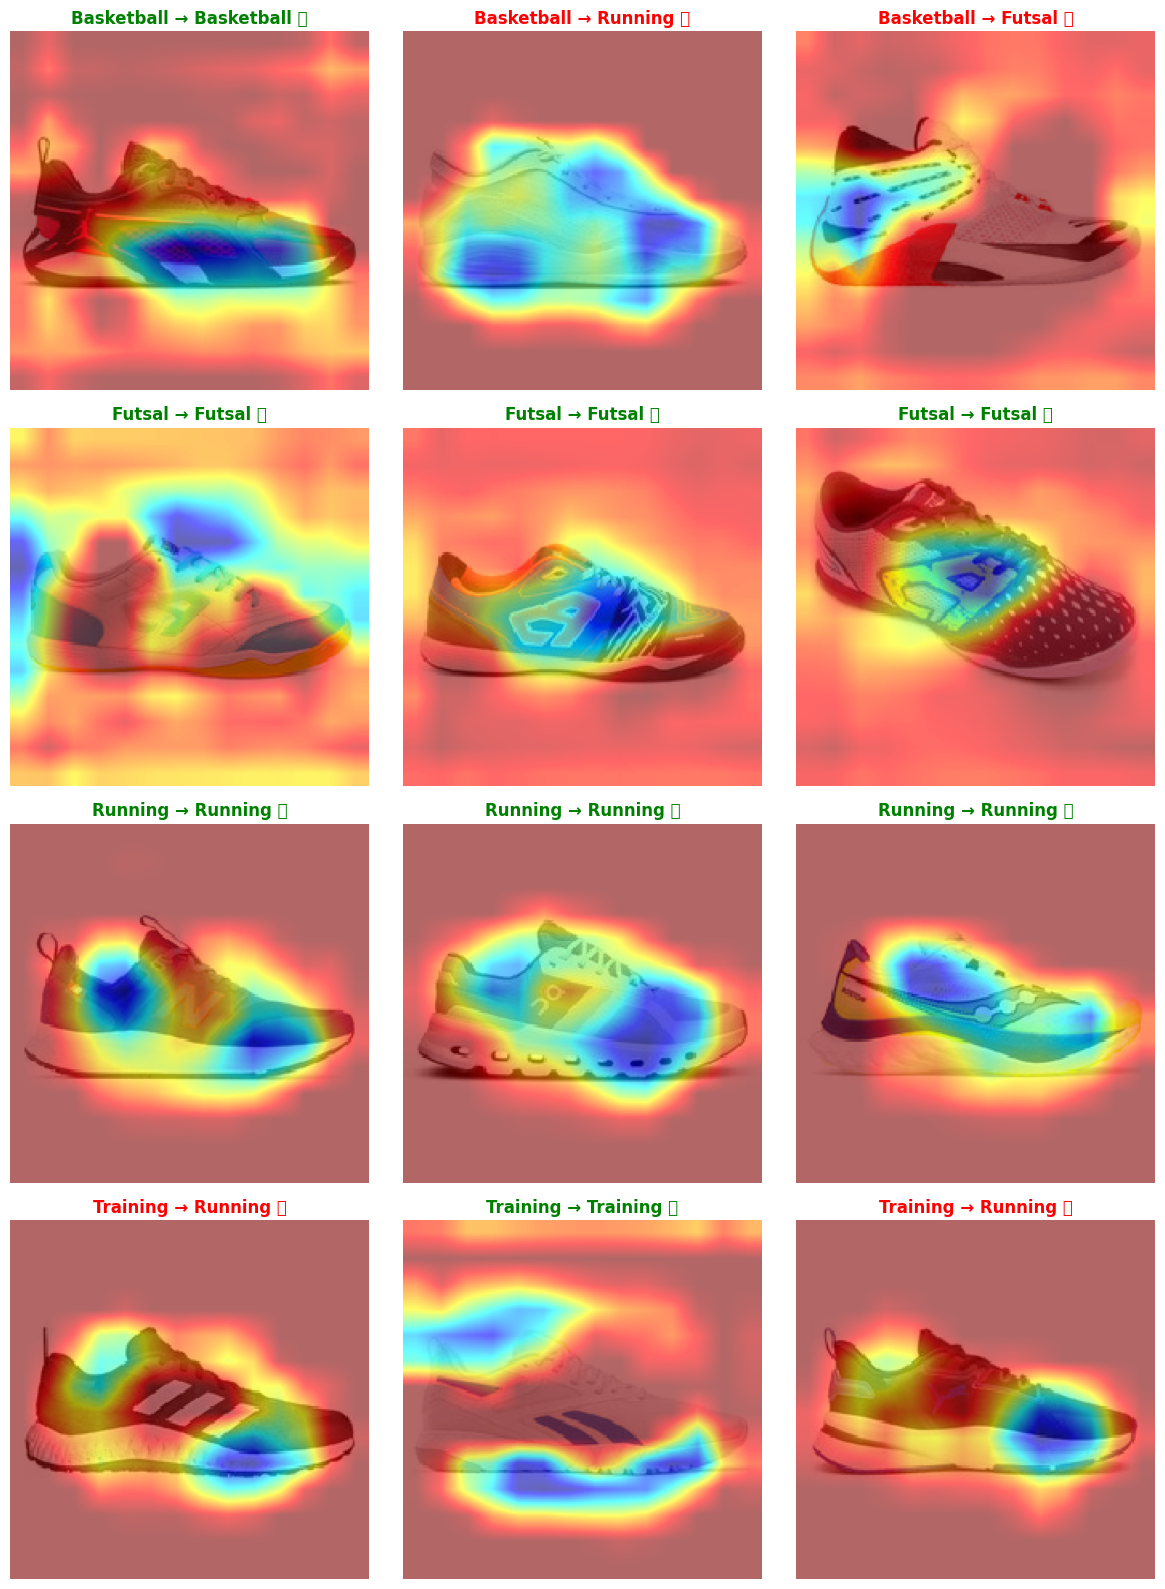

In [34]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import cv2

# ✅ ตั้งค่า
test_dir = "Test"  # เปลี่ยนเป็นโฟลเดอร์ Test
num_images = 3  # ✅ จำนวนรูปที่ต้องการสุ่มต่อคลาส
class_names = ["Basketball", "Futsal", "Running", "Training"]

# ✅ กำหนด Last Conv Layer ของแต่ละโมเดล
last_conv_layer_dict = {
    "VGG16": "block5_conv3",
    "ResNet50": "conv5_block3_out",
    "EfficientNetB0": "top_conv",
    "MobileNetV2": "Conv_1"
}

# ✅ ฟังก์ชันสร้าง Grad-CAM
def generate_grad_cam(model, img_path, class_names, last_conv_layer_name, alpha=0.4):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # ✅ ดึงโมเดล Backbone
    grad_model = tf.keras.models.Model(
        [model.input],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # ✅ คำนวณ Gradient
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        predicted_class = np.argmax(predictions[0])
        loss = predictions[:, predicted_class]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)[0]

    # ✅ แปลง Heatmap
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))  # ❌ เอา .numpy() ออก
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # ✅ ซ้อน Heatmap กับภาพต้นฉบับ
    img_with_heatmap = cv2.addWeighted(np.array(img), alpha, heatmap, 1 - alpha, 0)

    return img_with_heatmap, class_names[predicted_class]

# ✅ แสดงผลหลายภาพ
fig, axes = plt.subplots(len(class_names), num_images, figsize=(num_images * 4, len(class_names) * 4))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(test_dir, class_name)
    image_files = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    selected_images = random.sample(image_files, min(num_images, len(image_files)))  # ✅ สุ่มเลือก

    for j, image_file in enumerate(selected_images):
        image_path = os.path.join(class_path, image_file)

        # ✅ ใช้ Grad-CAM
        grad_cam_img, predicted_label = generate_grad_cam(
            model, image_path, class_names, last_conv_layer_dict["VGG16"]
        )

        # ✅ ตรวจสอบว่าโมเดลทำนายถูกหรือผิด
        actual_label = class_name
        correct = predicted_label == actual_label
        color = "green" if correct else "red"
        marker = "✅" if correct else "❌"

        # ✅ แสดงภาพ Grad-CAM และผลลัพธ์
        axes[i, j].imshow(grad_cam_img)
        axes[i, j].set_title(f"{actual_label} → {predicted_label} {marker}", color=color, fontsize=12, fontweight="bold")
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()
